In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyodbc

conn = pyodbc.connect(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=DESKTOP-9U487JR\\SQLEXPRESS;"
    "DATABASE=CHURN;"
    "Trusted_Connection=yes;"
)

query = "SELECT * FROM C1"

df = pd.read_sql(query, conn)

print(df.head())

   Customer_ID  Age  Gender             City  Occupation  Monthly_Income  \
0       100000   59  Female  Bangalore        Retired              14208   
1       100001   23  Female  Pune             Business             51870   
2       100002   30  Female  Bhopal           Student              11162   
3       100003   48  Female  Delhi            Freelancer           38803   
4       100004   52  Male    Bhopal           Retired              12850   

  Account_Type  Account_Tenure_Years  Avg_Monthly_Balance  Credit_Score  ...  \
0      Current                     8                55462           615  ...   
1      Current                     5                 5470           641  ...   
2      Savings                     8                66452           563  ...   
3      Savings                     7                34953           526  ...   
4      Savings                     7                52718           738  ...   

   Relationship_Manager_Assigned  Competitor_Bank_Usage  \
0  

C:\Users\DELL\AppData\Local\Temp\ipykernel_15192\2436330098.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


In [14]:
print(df.shape)

print(df.info())

print(df.describe())

print(df.dtypes)

(4250, 35)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4250 entries, 0 to 4249
Data columns (total 35 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Customer_ID                    4250 non-null   int64  
 1   Age                            4250 non-null   int64  
 2   Gender                         4250 non-null   object 
 3   City                           4250 non-null   object 
 4   Occupation                     4250 non-null   object 
 5   Monthly_Income                 4250 non-null   int64  
 6   Account_Type                   4250 non-null   object 
 7   Account_Tenure_Years           4250 non-null   int64  
 8   Avg_Monthly_Balance            4250 non-null   int64  
 9   Credit_Score                   4250 non-null   int64  
 10  Number_of_Transactions         4250 non-null   int64  
 11  Last_Transaction_Days_Ago      4250 non-null   int64  
 12  Internet_Banking_Active        4250 n

---Gender---
        Count  percentage
Gender                   
Male     2135       50.24
Female   2115       49.76


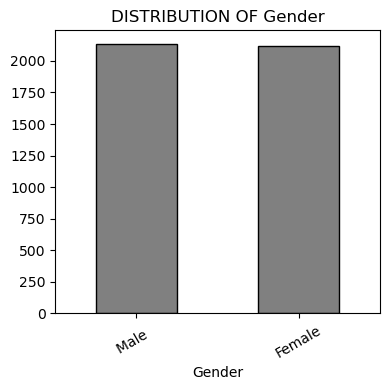

---City---
                 Count  percentage
City                              
Hyderabad          576       13.55
Kolkata            559       13.15
Mumbai             548       12.89
Chennai            541       12.73
Bhopal             526       12.38
Delhi              515       12.12
Pune               501       11.79
Bangalore          484       11.39


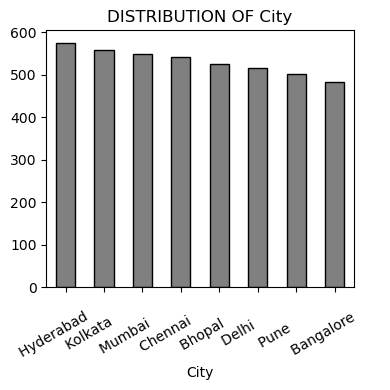

---Occupation---
            Count  percentage
Occupation                   
Salaried      744       17.51
Freelancer    734       17.27
Retired       702       16.52
Business      701       16.49
Student       701       16.49
Government    668       15.72


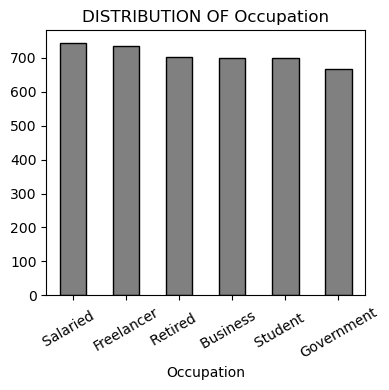

---Account_Type---
              Count  percentage
Account_Type                   
Savings        1469       34.56
Current        1427       33.58
Salary         1354       31.86


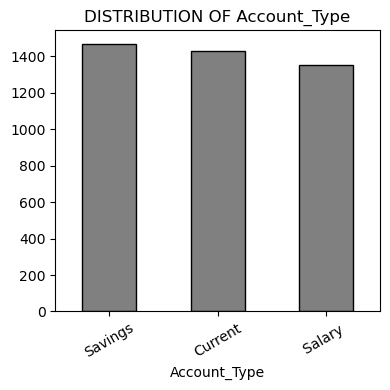

---Loan_Status---
             Count  percentage
Loan_Status                   
No Loan       2449       57.62
Approved      1097       25.81
Rejected       419        9.86
Pending        285        6.71


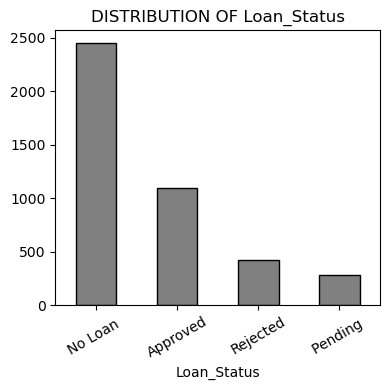

---Debit_Card_Usage---
                  Count  percentage
Debit_Card_Usage                   
Medium             1480       34.82
Low                1389       32.68
High               1381       32.49


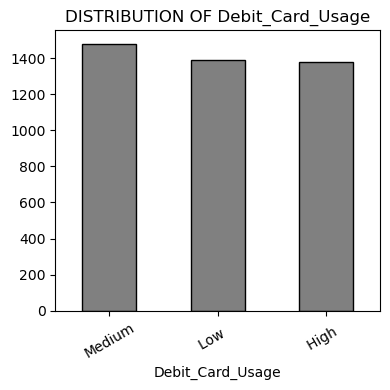

---Cashback_Offer_Response---
                         Count  percentage
Cashback_Offer_Response                   
Accepted                  1439       33.86
Ignored                   1428       33.60
Rejected                  1383       32.54


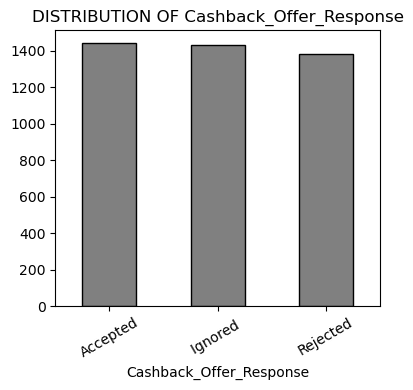

---Retention_Recommendation---
                                  Count  percentage
Retention_Recommendation                           
Loyalty rewards program            1114       26.21
Cross-sell FD and insurance         965       22.71
Send cashback offers                810       19.06
Offer zero-balance upgrade          559       13.15
Assign priority customer support    507       11.93
Provide secured loan offer          295        6.94


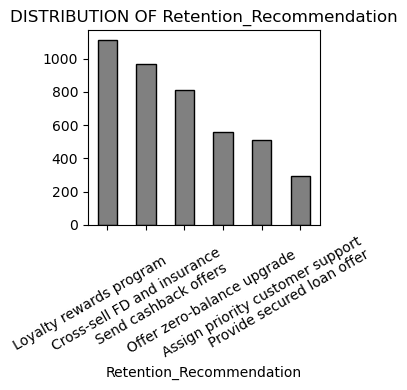

In [2]:
#CATEGORICAL COLUMNS--

categorical_cols=['Gender','City','Occupation','Account_Type','Loan_Status','Debit_Card_Usage','Cashback_Offer_Response','Retention_Recommendation']
for col in categorical_cols:
    print(f'---{col}---')
    counts=df[col].value_counts()
    percentages= round(df[col].value_counts(normalize=True)*100,2)
    summary= pd.DataFrame({
        'Count':counts, 'percentage': percentages
    })
    print(summary)
    plt.figure(figsize=[4,4])
    df[col].value_counts().plot(kind='bar',color='grey',edgecolor='black')
    plt.title(f'DISTRIBUTION OF {col}')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()
    


---DISTRIBUTION OF Age ---
MEAN IS 42.41
MEDIAN IS 42.00
STANDARD DEVIATION 12.63
MINIMUM IS 21.00
MAX IS 64.00
SKEWNESS IS 0.01
KURTOSIS IS -1.20
distribution is approximately symmertic
---DISTRIBUTION OF Monthly_Income ---
MEAN IS 64774.50
MEDIAN IS 64105.50
STANDARD DEVIATION 24224.94
MINIMUM IS 15000.00
MAX IS 145573.00
SKEWNESS IS 0.12
KURTOSIS IS -0.36
distribution is approximately symmertic
---DISTRIBUTION OF Account_Tenure_Years ---
MEAN IS 7.52
MEDIAN IS 8.00
STANDARD DEVIATION 4.04
MINIMUM IS 1.00
MAX IS 14.00
SKEWNESS IS -0.02
KURTOSIS IS -1.21
distribution is approximately symmertic
---DISTRIBUTION OF Avg_Monthly_Balance ---
MEAN IS 40953.60
MEDIAN IS 39980.50
STANDARD DEVIATION 27614.06
MINIMUM IS 500.00
MAX IS 154893.00
SKEWNESS IS 0.40
KURTOSIS IS -0.35
distribution is approximately symmertic
---DISTRIBUTION OF Credit_Score ---
MEAN IS 690.03
MEDIAN IS 688.00
STANDARD DEVIATION 79.22
MINIMUM IS 355.00
MAX IS 900.00
SKEWNESS IS -0.03
KURTOSIS IS 0.01
distribution is appro

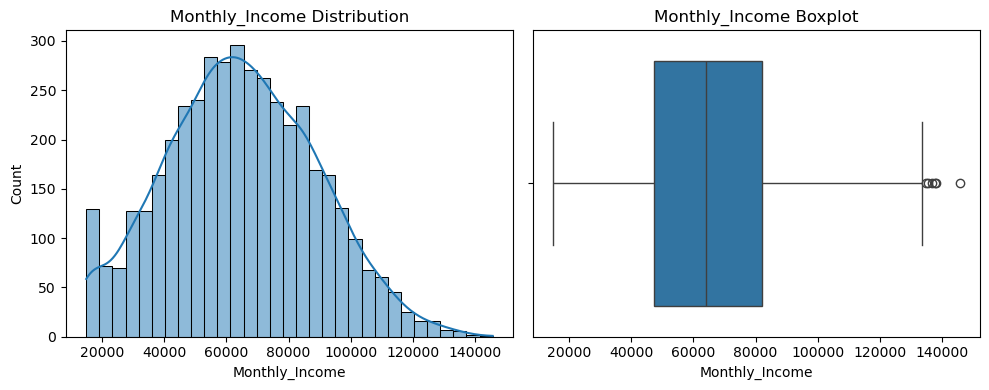

0.11646900179866532


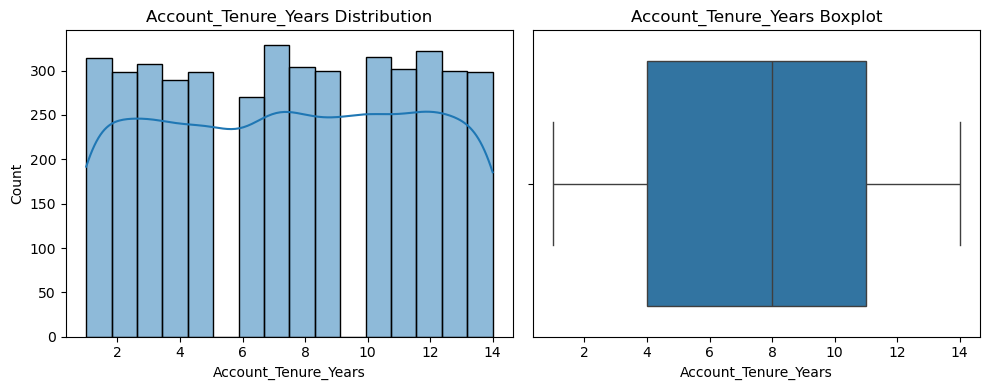

-0.02129302168976895


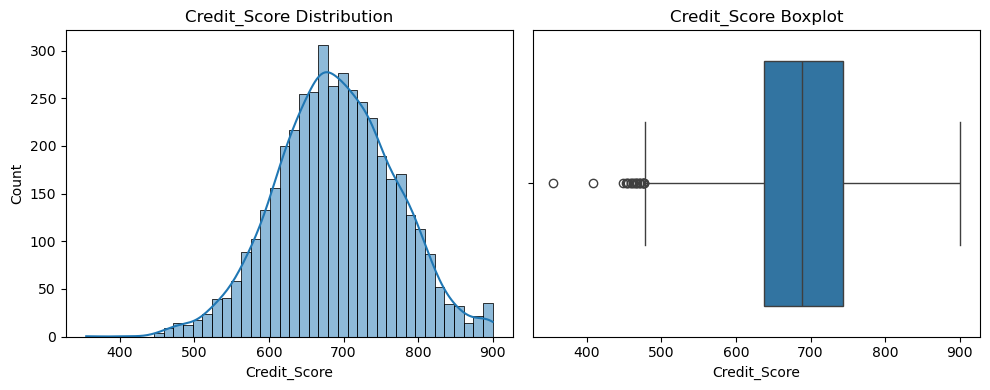

-0.027647909427758167


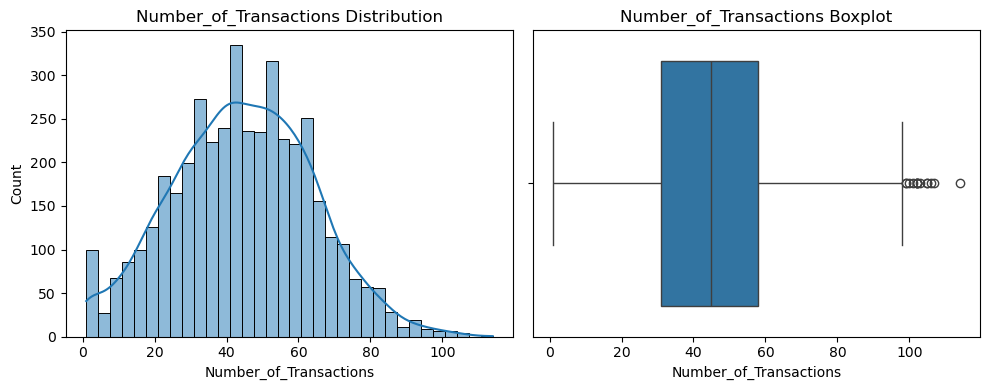

0.05179204353807322


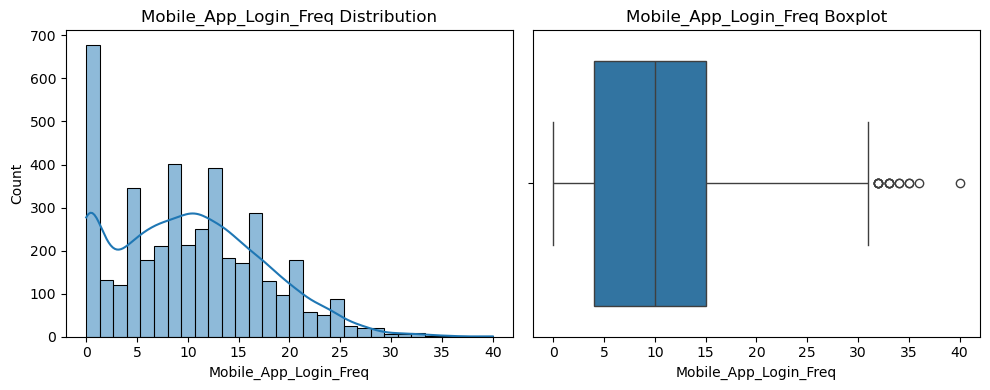

0.42196579374887305


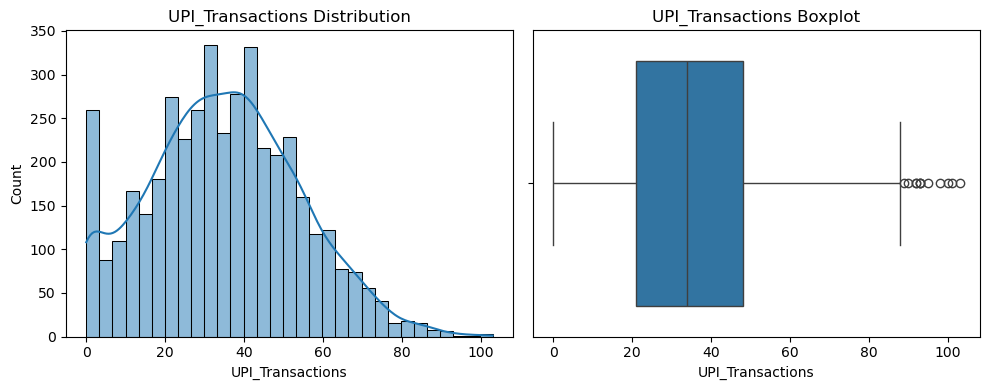

0.19390027828903506


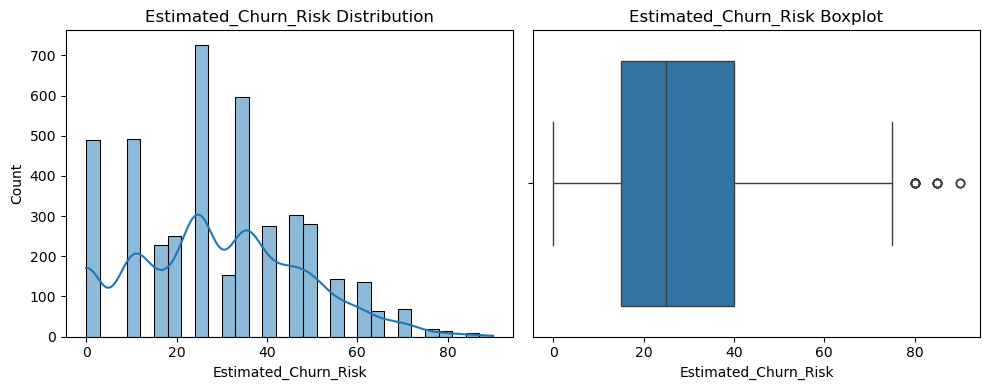

0.27129717302583334


In [7]:
#---NUMERICAL COLUMNS---
num_cols=['Age','Monthly_Income','Account_Tenure_Years','Avg_Monthly_Balance','Credit_Score','Number_of_Transactions','Last_Transaction_Days_Ago','Mobile_App_Login_Freq','UPI_Transactions','Complaint_Count','Customer_Service_Calls','Reward_Points_Used','Financial_Stress_Score','Digital_Engagement_Score','Product_Holding_Count','Estimated_Churn_Risk']
for col in num_cols:
    print(f'---DISTRIBUTION OF {col} ---')
    count = df[col].value_counts()
    percentages= round(df[col].value_counts(normalize=True)*100,2)
    summary= pd.DataFrame({'COUNT':count,'PERCENTAGE': percentages})
    print(f'MEAN IS {df[col].mean():.2f}')
    print(f'MEDIAN IS {df[col].median():.2f}')
    print(f'STANDARD DEVIATION {df[col].std():.2f}')
    print(f'MINIMUM IS {df[col].min():.2f}')
    print(f'MAX IS {df[col].max():.2f}')
    print(f'SKEWNESS IS {df[col].skew():.2f}')
    print(f'KURTOSIS IS {df[col].kurtosis():.2f}')
    if abs (df[col].skew())>1:
        print("distribution is  highly skewed")
    elif abs(df[col].skew())>0.5:
        print("distribution is moderately skewed ")
    else:
        print("distribution is approximately symmertic")
for col in ['Monthly_Income','Account_Tenure_Years','Credit_Score','Number_of_Transactions','Mobile_App_Login_Freq','UPI_Transactions','Estimated_Churn_Risk']:
    fig,axes=plt.subplots(1,2,figsize=(10,4))
    sns.histplot(df[col], kde=True,ax=axes[0])
    axes[0].set_title(f'{col} Distribution')

    sns.boxplot(x=df[col],ax=axes[1])
    axes[1].set_title(f'{col} Boxplot')

    plt.tight_layout()
    plt.show()
    print(df[col].skew())
    
    
    


In [8]:
df.isnull().sum().sort_values(ascending=False)

Customer_ID                      0
Competitor_Bank_Usage            0
Credit_Card_Utilization          0
Reward_Points_Used               0
FD_Investment                    0
Insurance_Product                0
Salary_Account                   0
Relationship_Manager_Assigned    0
Cashback_Offer_Response          0
Customer_Service_Calls           0
Avg_UPI_Spend                    0
Financial_Stress_Score           0
Digital_Engagement_Score         0
Product_Holding_Count            0
Estimated_Churn_Risk             0
Churn_Status                     0
Debit_Card_Usage                 0
Complaint_Count                  0
Age                              0
Avg_Monthly_Balance              0
Gender                           0
City                             0
Occupation                       0
Monthly_Income                   0
Account_Type                     0
Account_Tenure_Years             0
Credit_Score                     0
Loan_Status                      0
Number_of_Transactio

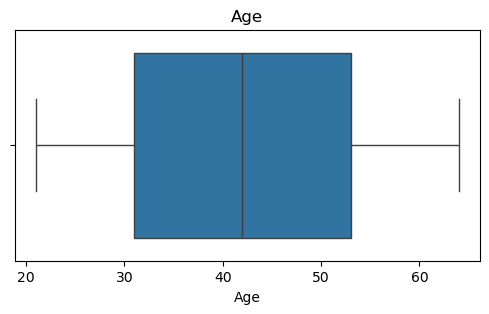

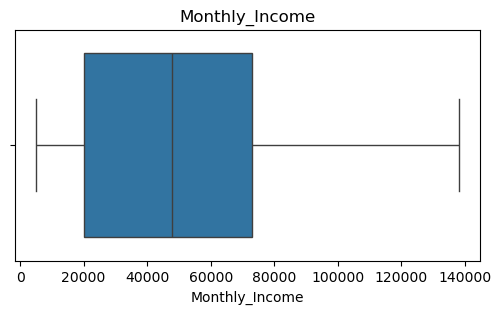

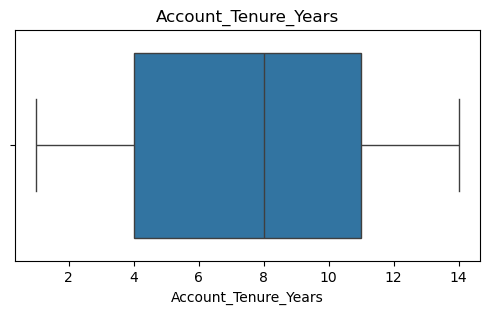

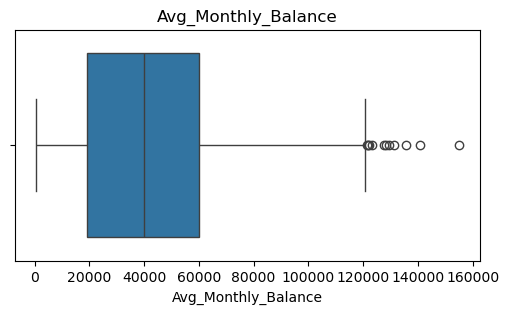

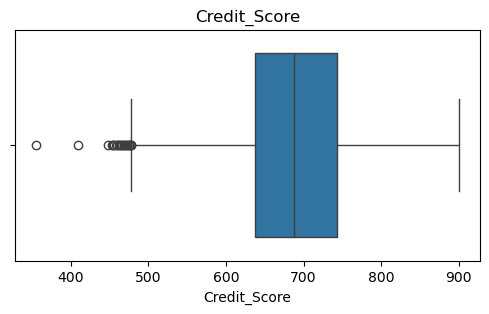

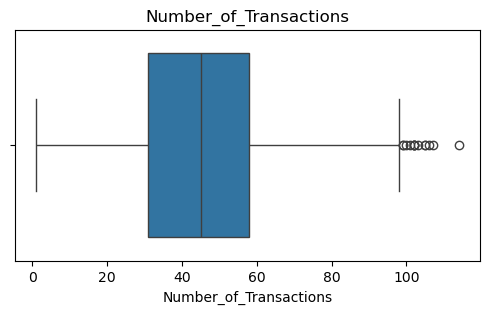

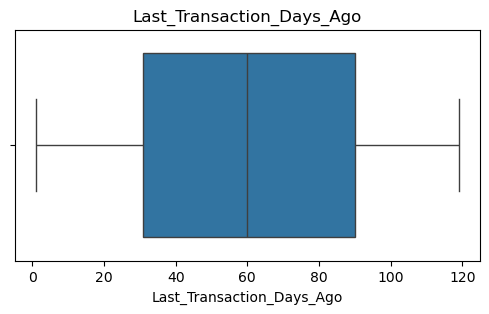

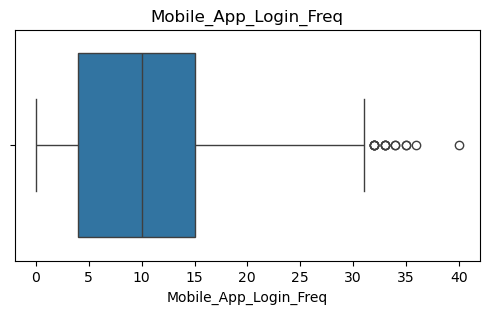

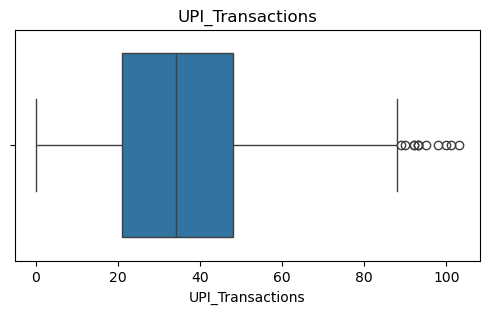

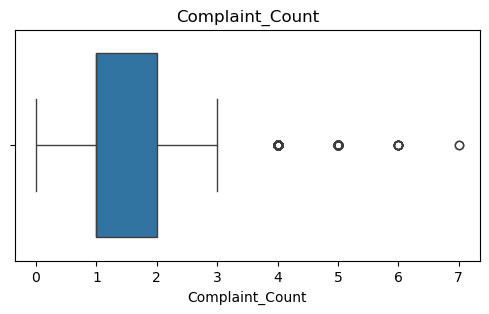

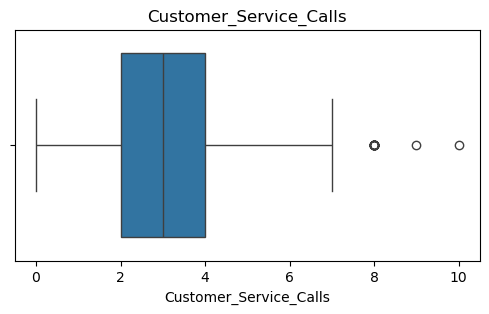

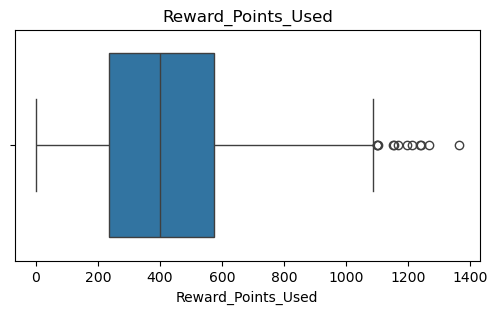

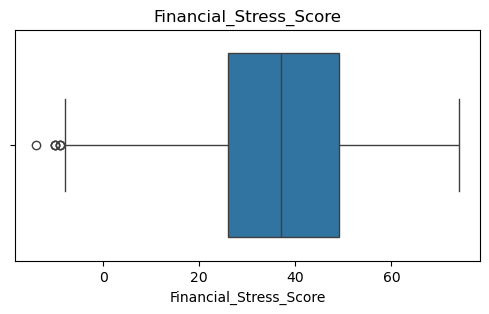

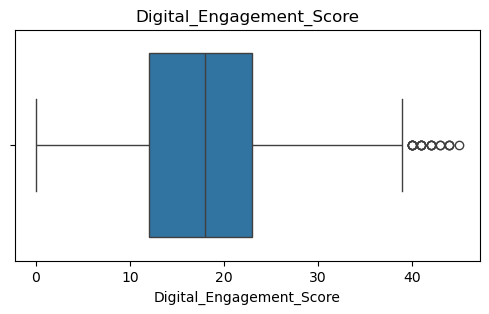

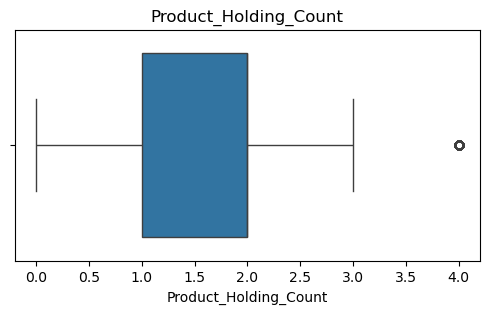

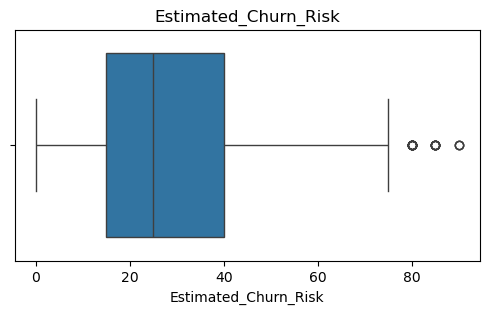

In [4]:
#outlier detection

num_cols=['Age','Monthly_Income','Account_Tenure_Years','Avg_Monthly_Balance','Credit_Score','Number_of_Transactions','Last_Transaction_Days_Ago','Mobile_App_Login_Freq','UPI_Transactions','Complaint_Count','Customer_Service_Calls','Reward_Points_Used','Financial_Stress_Score','Digital_Engagement_Score','Product_Holding_Count','Estimated_Churn_Risk']

for col in num_cols:

    plt.figure(figsize=(6,3))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

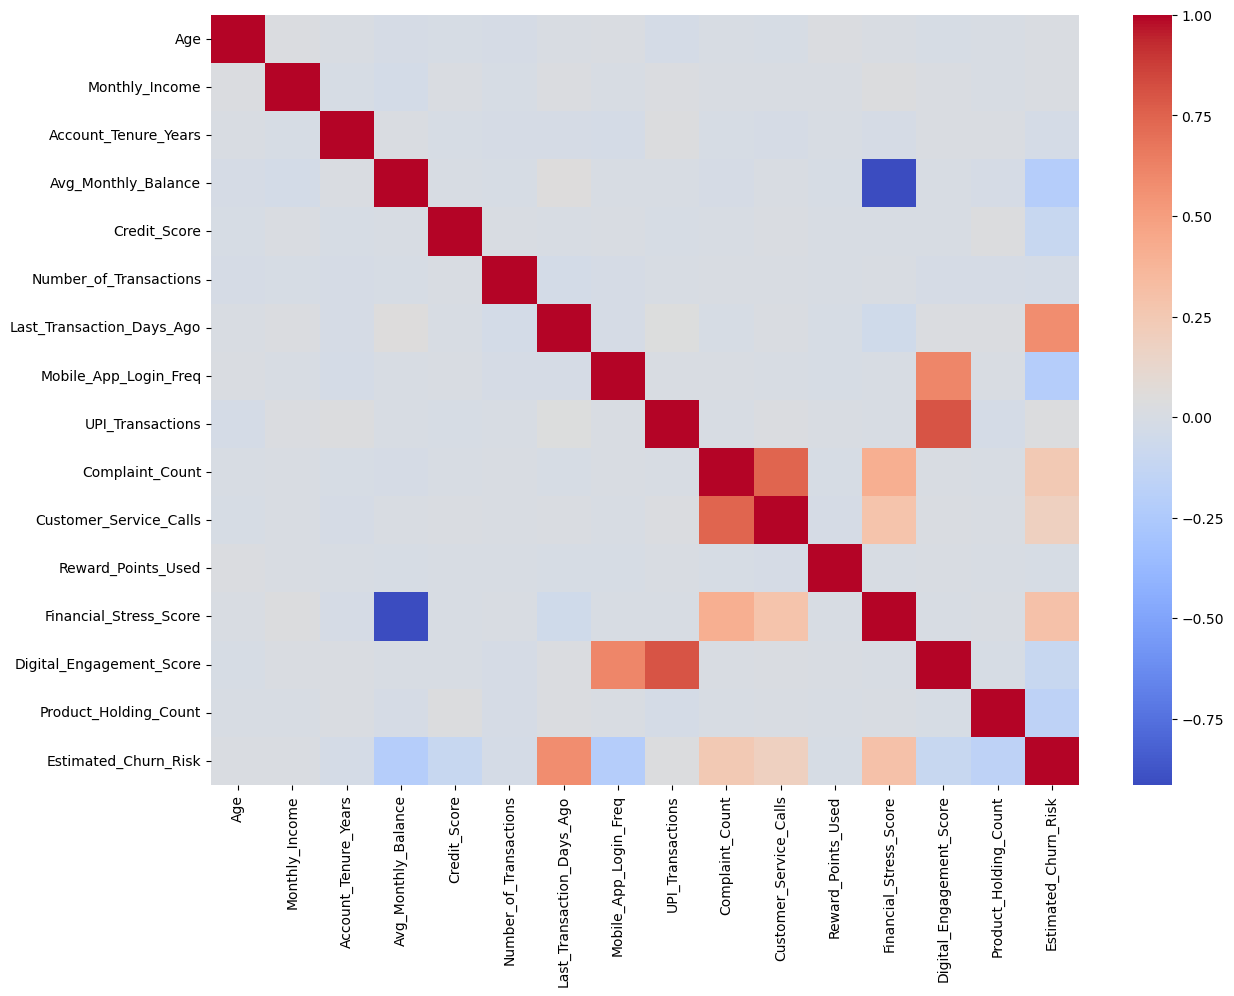

In [5]:
plt.figure(figsize=(14,10))

corr = df[num_cols].corr()

sns.heatmap(
corr,
annot=False,
cmap='coolwarm'
)

plt.show()

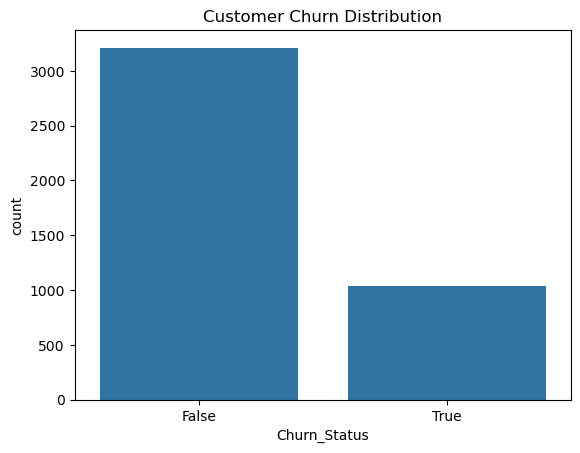

In [13]:
#churn distribution

sns.countplot(x='Churn_Status', data=df)

plt.title("Customer Churn Distribution")

plt.show()

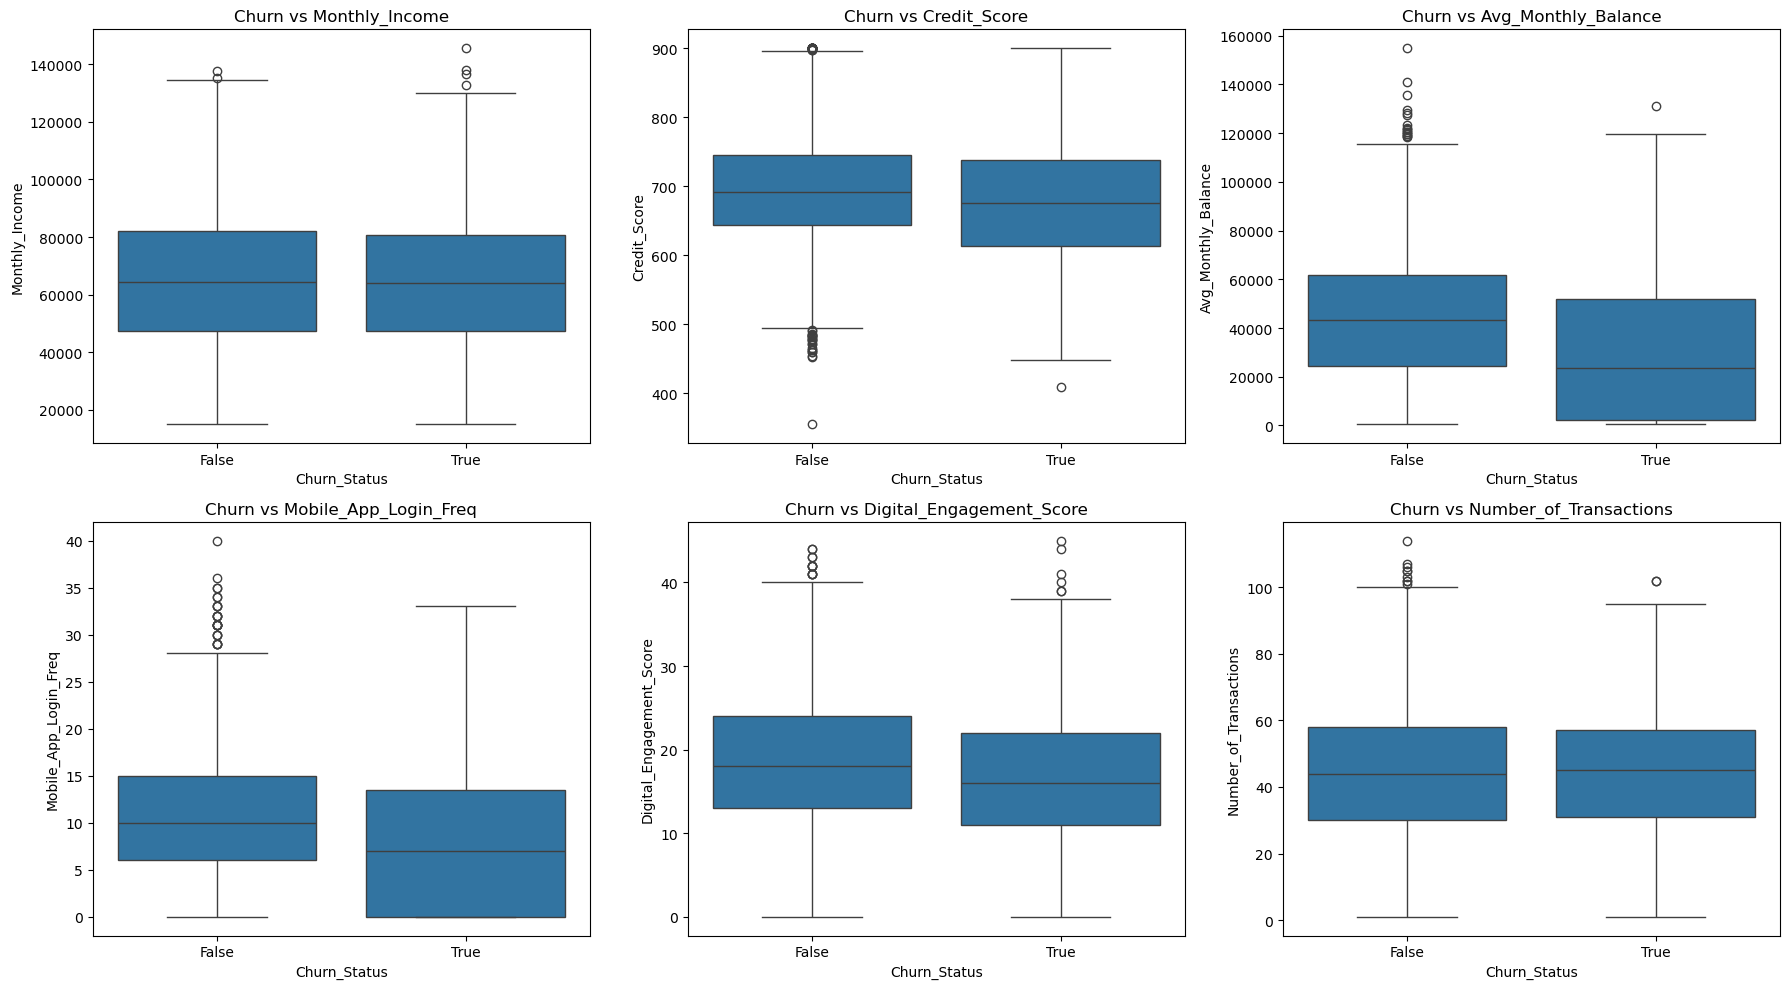

In [19]:
# Relationship Analysis 
#---

#Churn vs Income
#Churn vs Credit Score
#Churn vs Balance

#Churn vs App Usage
#Churn vs Digital Engagement
#Churn vs Transactions

relationship_cols = [
'Monthly_Income',
'Credit_Score',
'Avg_Monthly_Balance',
'Mobile_App_Login_Freq',
'Digital_Engagement_Score',
'Number_of_Transactions'
]

fig, axes = plt.subplots(2, 3, figsize=(18,10))

axes = axes.flatten()

for i, col in enumerate(relationship_cols):

    sns.boxplot(
        x='Churn_Status',
        y=col,
        data=df,
        ax=axes[i]
    )

    axes[i].set_title(
        f'Churn vs {col}'
    )

plt.tight_layout()

plt.show()


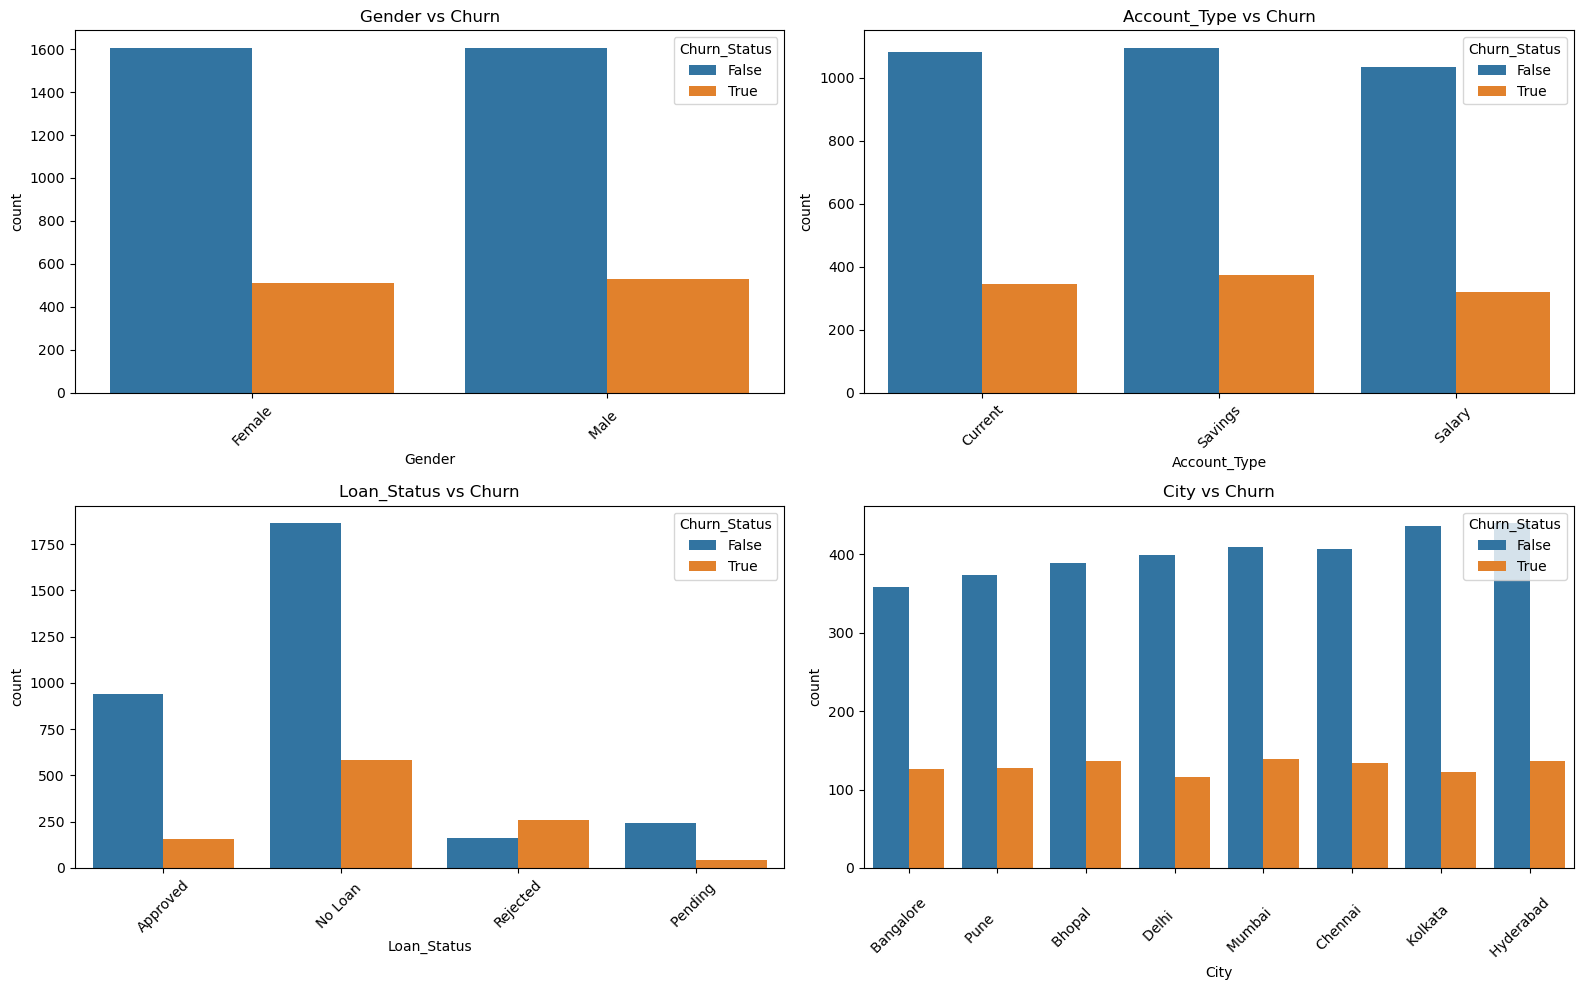

In [18]:
cat_cols = [
'Gender',
'Account_Type',
'Loan_Status',
'City'
]

fig, axes = plt.subplots(2,2, figsize=(16,10))

axes = axes.flatten()

for i, col in enumerate(cat_cols):

    sns.countplot(
        x=col,
        hue='Churn_Status',
        data=df,
        ax=axes[i]
    )

    axes[i].tick_params(
        axis='x',
        rotation=45
    )

    axes[i].set_title(
        f'{col} vs Churn'
    )

plt.tight_layout()

plt.show()

In [4]:
from scipy.stats import ttest_ind

# T-TEST — Churned vs Not Churned
print("=" * 60)
print("HYPOTHESIS TESTING — INDEPENDENT SAMPLES T-TEST")
print("H0: No difference in means between churned and not churned")
print("H1: Significant difference exists (alpha = 0.05)")
print("=" * 60)

churned     = df[df['Churn_Status'] == 'Yes']
not_churned = df[df['Churn_Status'] == 'No']

test_cols = [
    'Avg_Monthly_Balance',
    'Credit_Score',
    'Digital_Engagement_Score',
    'Financial_Stress_Score',
    'Last_Transaction_Days_Ago',
    'Mobile_App_Login_Freq',
    'Complaint_Count'
]

results = []
for col in test_cols:
    t_stat, p_val = ttest_ind(
        churned[col].dropna(),
        not_churned[col].dropna()
    )
    result = 'REJECT H0 ✅ SIGNIFICANT' if p_val < 0.05 else 'FAIL TO REJECT ❌'
    results.append({
        'Feature':           col,
        't-statistic':       round(t_stat, 4),
        'p-value':           round(p_val, 6),
        'Mean Churned':      round(churned[col].mean(), 2),
        'Mean Not Churned':  round(not_churned[col].mean(), 2),
        'Result':            result
    })
    print(f"\n{col}")
    print(f"  Mean Churned     = {churned[col].mean():.2f}")
    print(f"  Mean Not Churned = {not_churned[col].mean():.2f}")
    print(f"  t = {t_stat:.4f}   p = {p_val:.6f}   → {result}")

results_df = pd.DataFrame(results)
print("\n\nSUMMARY TABLE:")
print(results_df[['Feature','p-value','Result']].to_string(index=False))

HYPOTHESIS TESTING — INDEPENDENT SAMPLES T-TEST
H0: No difference in means between churned and not churned
H1: Significant difference exists (alpha = 0.05)

Avg_Monthly_Balance
  Mean Churned     = nan
  Mean Not Churned = nan
  t = nan   p = nan   → FAIL TO REJECT ❌

Credit_Score
  Mean Churned     = nan
  Mean Not Churned = nan
  t = nan   p = nan   → FAIL TO REJECT ❌

Digital_Engagement_Score
  Mean Churned     = nan
  Mean Not Churned = nan
  t = nan   p = nan   → FAIL TO REJECT ❌

Financial_Stress_Score
  Mean Churned     = nan
  Mean Not Churned = nan
  t = nan   p = nan   → FAIL TO REJECT ❌

Last_Transaction_Days_Ago
  Mean Churned     = nan
  Mean Not Churned = nan
  t = nan   p = nan   → FAIL TO REJECT ❌

Mobile_App_Login_Freq
  Mean Churned     = nan
  Mean Not Churned = nan
  t = nan   p = nan   → FAIL TO REJECT ❌

Complaint_Count
  Mean Churned     = nan
  Mean Not Churned = nan
  t = nan   p = nan   → FAIL TO REJECT ❌


SUMMARY TABLE:
                  Feature  p-value    

In [6]:
from scipy.stats import chi2_contingency

# CHI-SQUARE TEST — Categorical vs Churn
print("=" * 60)
print("CHI-SQUARE TEST — CATEGORICAL VARIABLES vs CHURN")
print("H0: Variable is INDEPENDENT of churn")
print("H1: Variable is ASSOCIATED with churn (alpha = 0.05)")
print("=" * 60)

chi_cols = ['Gender', 'City', 'Occupation',
            'Account_Type', 'Loan_Status']

for col in chi_cols:
    contingency_table = pd.crosstab(df[col], df['Churn_Status'])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    result = 'REJECT H0 ✅ SIGNIFICANT' if p < 0.05 else 'FAIL TO REJECT ❌'
    print(f"\n{col}")
    print(f"  chi2 = {chi2:.4f}   p = {p:.6f}   df = {dof}")
    print(f"  → {result}")

CHI-SQUARE TEST — CATEGORICAL VARIABLES vs CHURN
H0: Variable is INDEPENDENT of churn
H1: Variable is ASSOCIATED with churn (alpha = 0.05)

Gender
  chi2 = 0.1573   p = 0.691692   df = 1
  → FAIL TO REJECT ❌

City
  chi2 = 5.0522   p = 0.653589   df = 7
  → FAIL TO REJECT ❌

Occupation
  chi2 = 3.4304   p = 0.633939   df = 5
  → FAIL TO REJECT ❌

Account_Type
  chi2 = 1.2253   p = 0.541914   df = 2
  → FAIL TO REJECT ❌

Loan_Status
  chi2 = 385.8423   p = 0.000000   df = 3
  → REJECT H0 ✅ SIGNIFICANT


C:\Users\DELL\AppData\Local\Temp\ipykernel_16704\3018608798.py:31: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


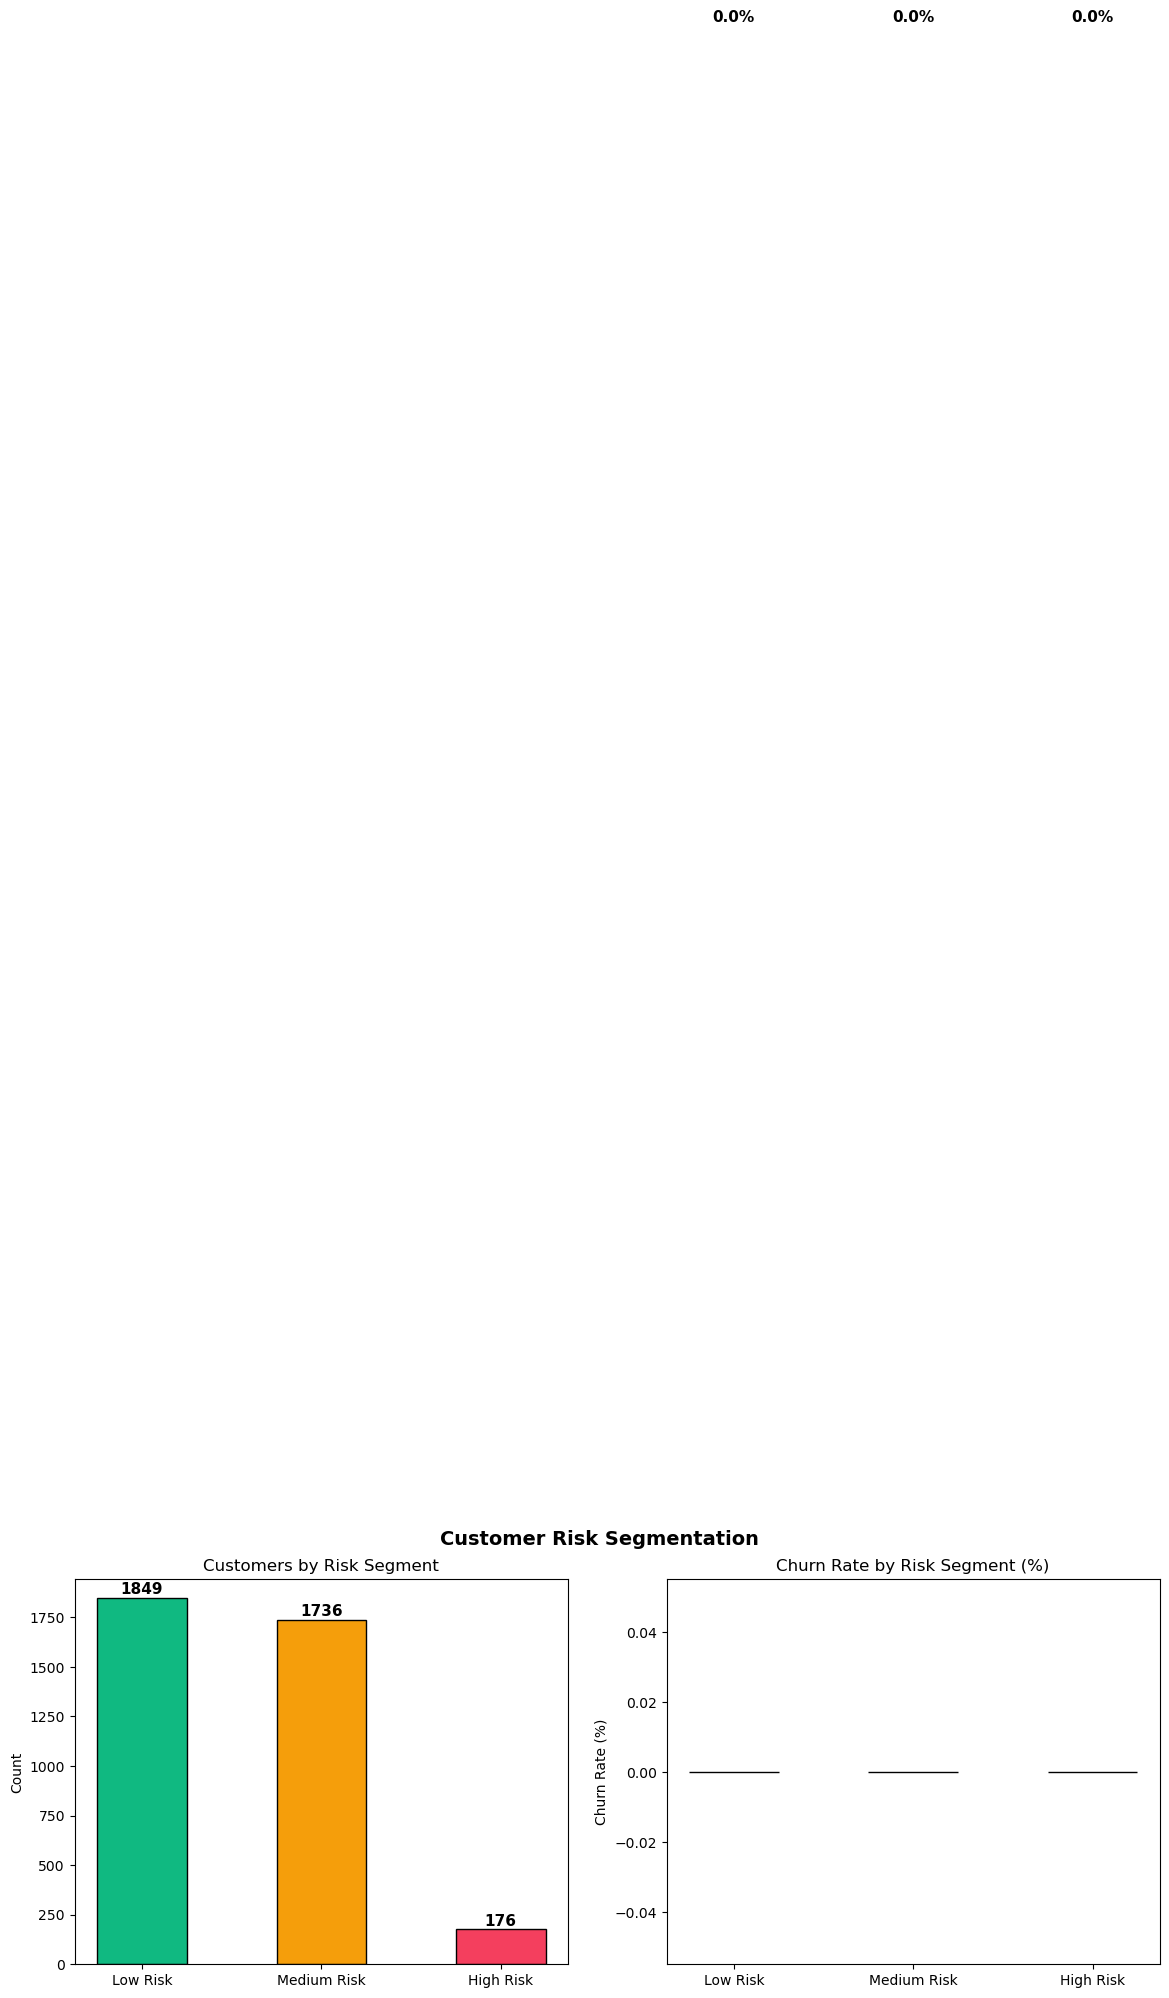

In [7]:
# RISK SEGMENTS — Low / Medium / High
df['Risk_Segment'] = pd.cut(
    df['Estimated_Churn_Risk'],
    bins=[0, 30, 60, 100],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

seg_count = df['Risk_Segment'].value_counts().sort_index()
axes[0].bar(seg_count.index, seg_count.values,
            color=['#10b981', '#f59e0b', '#f43f5e'],
            edgecolor='black', width=0.5)
axes[0].set_title('Customers by Risk Segment', fontsize=12)
axes[0].set_ylabel('Count')
for i, v in enumerate(seg_count.values):
    axes[0].text(i, v + 20, str(v), ha='center',
                 fontweight='bold', fontsize=11)

seg_churn = df.groupby('Risk_Segment', observed=True)['Churn_Binary'].mean() * 100
axes[1].bar(seg_churn.index, seg_churn.values,
            color=['#10b981', '#f59e0b', '#f43f5e'],
            edgecolor='black', width=0.5)
axes[1].set_title('Churn Rate by Risk Segment (%)', fontsize=12)
axes[1].set_ylabel('Churn Rate (%)')
for i, v in enumerate(seg_churn.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center',
                 fontweight='bold', fontsize=11)

plt.suptitle('Customer Risk Segmentation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [20]:
print(df.shape)

(4250, 35)


In [21]:
df.columns[-10:]

Index(['Relationship_Manager_Assigned', 'Competitor_Bank_Usage',
       'Cashback_Offer_Response', 'Avg_UPI_Spend', 'Financial_Stress_Score',
       'Digital_Engagement_Score', 'Product_Holding_Count',
       'Estimated_Churn_Risk', 'Churn_Status', 'Retention_Recommendation'],
      dtype='object')